In [ ]:
import pandas as pd
import numpy as np

# 예제 유전자형 데이터 (SNP 데이터)
genotype_data = {
    'SNP': ['rs1', 'rs2', 'rs3', 'rs4'], #마커로 쓸수 있는 스닙
    'Sample1': [0, 1, 0, 2], #타입 3가지로 구성
    'Sample2': [1, 1, 0, 0],
    'Sample3': [2, 0, 1, 2],
    'Sample4': [0, 0, 0, 1]
}

# 예제 표현형 데이터 (질병 여부, 연속형 데이터)
phenotype_data = {
    'Sample': ['Sample1', 'Sample2', 'Sample3', 'Sample4'],
    'DiseaseStatus': [0, 1, 0, 1] #질병 여부
}

genotype_df = pd.DataFrame(genotype_data)
phenotype_df = pd.DataFrame(phenotype_data)

In [ ]:
# 유전자형 데이터 전치
genotype_df = genotype_df.set_index('SNP').T

# 표현형 데이터 병합
merged_data = genotype_df.merge(phenotype_df, left_index=True, right_on='Sample')
merged_data.set_index('Sample', inplace=True)

In [ ]:
merged_data

,rs1,rs2,rs3,rs4,DiseaseStatus
Sample,,,,,
Sample1,0,1,0,2,0
Sample2,1,1,0,0,1
Sample3,2,0,1,2,0
Sample4,0,0,0,1,1


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 가상의 데이터 생성
np.random.seed(42)
num_samples = 1000
num_snps = 1000

# SNP 데이터 (0, 1, 2로 표현된 유전자형)
snps = np.random.randint(0, 3, size=(num_samples, num_snps))

# 가상의 표현형 데이터 (예: 질병 유무, 0 또는 1)
phenotype = np.random.randint(0, 2, size=num_samples)

# 데이터프레임 생성
snp_df = pd.DataFrame(snps, columns=[f"SNP_{i+1}" for i in range(num_snps)])
phenotype_df = pd.DataFrame(phenotype, columns=["Phenotype"])

In [ ]:
snp_df

,SNP_1,SNP_2,SNP_3,SNP_4,SNP_5,SNP_6,SNP_7,SNP_8,SNP_9,SNP_10,...,SNP_991,SNP_992,SNP_993,SNP_994,SNP_995,SNP_996,SNP_997,SNP_998,SNP_999,SNP_1000
0,2,0,2,2,0,0,2,1,2,2,...,1,2,1,2,1,1,1,2,2,0
1,2,2,2,2,0,2,1,1,2,2,...,1,1,2,0,0,0,2,1,2,2
2,1,0,0,2,0,2,2,1,1,1,...,1,0,1,1,0,2,0,0,1,1
3,1,1,2,2,2,1,1,1,2,1,...,0,2,0,0,1,0,2,1,2,1
4,0,1,1,0,0,2,2,0,0,0,...,0,0,1,1,0,0,1,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,1,0,0,1,2,2,1,1,0,...,2,1,2,2,1,1,1,0,2,0
996,2,0,1,1,0,1,0,1,0,0,...,1,2,1,1,1,2,2,1,2,2
997,1,2,2,2,1,2,2,1,1,2,...,1,1,1,2,0,2,2,0,1,1
998,2,0,0,2,1,1,2,0,2,1,...,1,2,2,1,1,2,0,2,0,1


In [ ]:
phenotype_df

,Phenotype
0,1
1,0
2,1
3,0
4,0
...,...
995,0
996,1
997,0
998,0


In [ ]:
# GWAS 분석(로지스틱 회귀)
betas = []
p_values = []

for snp in snp_df.columns:
    X = snp_df[[snp]]
    X = sm.add_constant(X)  # 상수항 추가
    y = phenotype_df["Phenotype"]

    model = sm.Logit(y, X)
    result = model.fit(disp=False)

    beta = result.params[1]  # SNP의 효과 크기 (베타값)
    p_value = result.pvalues[1]  # SNP의 p-value

    betas.append(beta)
    p_values.append(p_value)

# 베타값 및 p-value 데이터프레임 생성
gwas_results = pd.DataFrame({
    "SNP": snp_df.columns,
    "Beta": betas,
    "P-Value": p_values
})

In [ ]:
gwas_results #랜덤으로 만들어서 유의하지 않은 결과가 많음

,SNP,Beta,P-Value
0,SNP_1,-0.003498,0.963306
1,SNP_2,-0.075214,0.327244
2,SNP_3,0.094509,0.220629
3,SNP_4,0.044259,0.563396
4,SNP_5,-0.154756,0.047060
...,...,...,...
995,SNP_996,0.034759,0.648879
996,SNP_997,0.003044,0.968755
997,SNP_998,0.053486,0.494666
998,SNP_999,0.024718,0.748473


In [ ]:
# P-value 기준으로 정렬
gwas_results = gwas_results.sort_values(by="P-Value")

# 상위 10개 결과 출력
print(gwas_results.head(10))

         SNP      Beta   P-Value
236  SNP_237  0.223034  0.004130
860  SNP_861 -0.217691  0.005391
86    SNP_87 -0.198035  0.010155
350  SNP_351  0.201991  0.010896
773  SNP_774  0.199071  0.011085
161  SNP_162  0.195987  0.011296
474  SNP_475 -0.199002  0.011462
37    SNP_38  0.200142  0.011579
452  SNP_453 -0.197346  0.012054
627  SNP_628  0.194970  0.012865


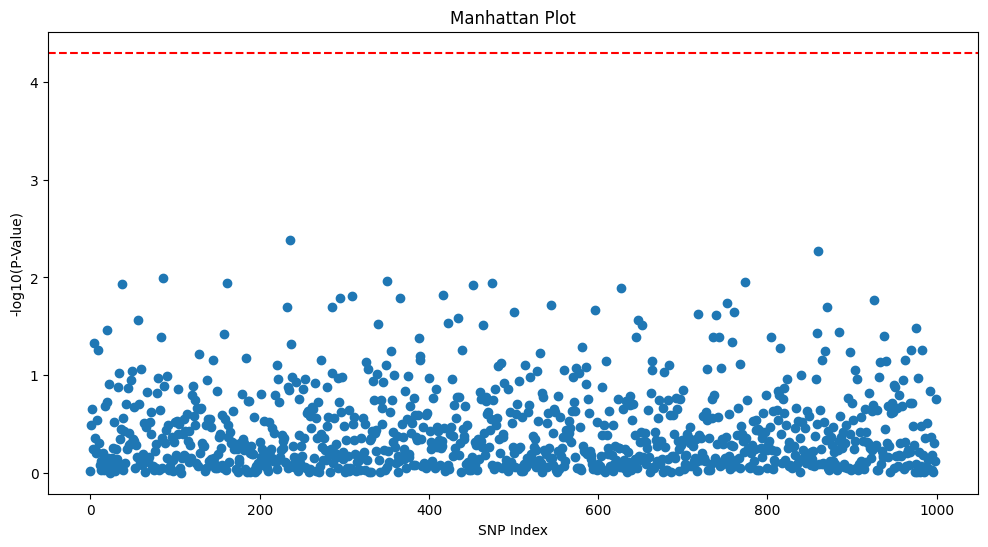

In [ ]:
# Manhattan Plot
plt.figure(figsize=(12, 6))
plt.plot(range(len(p_values)), -np.log10(p_values), 'o')
plt.axhline(y=-np.log10(0.05 / num_snps), color='r', linestyle='--')  # 보정된 유의수준
plt.xlabel('SNP Index')
plt.ylabel('-log10(P-Value)')
plt.title('Manhattan Plot')
plt.show()

In [ ]:
# PRS 계산
# gwas_results의 Beta 값을 snp_df의 열 순서에 맞게 정렬
beta_sorted = gwas_results.set_index("SNP").loc[snp_df.columns, "Beta"]
prs = snp_df.dot(beta_sorted)

# PRS와 표현형 간의 관계 분석
prs_df = pd.DataFrame(prs, columns=["PRS"])
prs_df["Phenotype"] = phenotype_df["Phenotype"]

# PRS와 질병 유무 간의 상관관계 확인
correlation = prs_df.corr()["PRS"]["Phenotype"]
print(f"PRS와 질병 유무 간의 상관관계: {correlation}")

PRS와 질병 유무 간의 상관관계: 0.6933128016141948


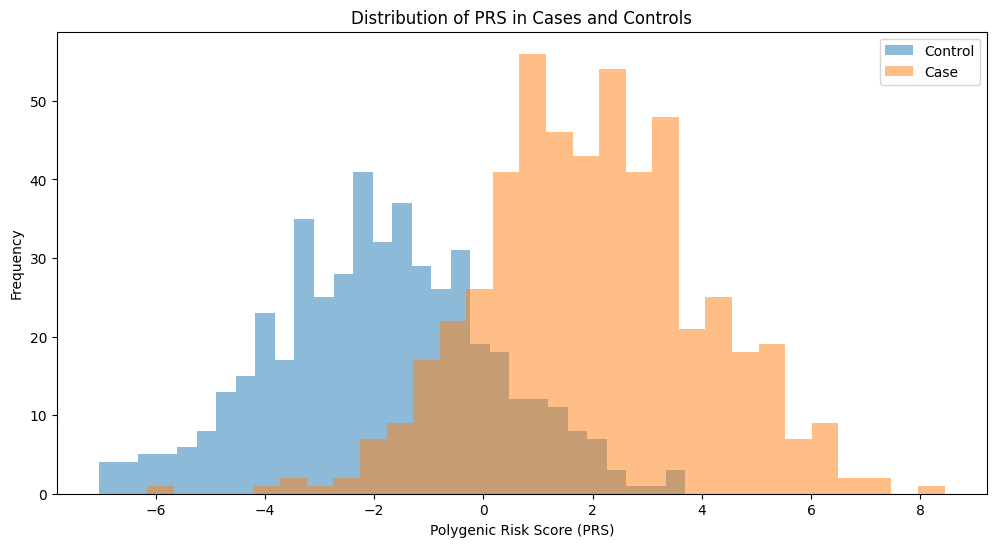

In [ ]:
# PRS 분포 시각화
plt.figure(figsize=(12, 6))
plt.hist(prs_df["PRS"][prs_df["Phenotype"] == 0], bins=30, alpha=0.5, label='Control')
plt.hist(prs_df["PRS"][prs_df["Phenotype"] == 1], bins=30, alpha=0.5, label='Case')
plt.xlabel('Polygenic Risk Score (PRS)')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of PRS in Cases and Controls')
plt.show()

In [ ]:
gwas_results["Beta"]

236    0.223034
860   -0.217691
86    -0.198035
350    0.201991
773    0.199071
         ...   
185    0.000996
258   -0.000867
551   -0.000862
107   -0.000613
23    -0.000291
Name: Beta, Length: 1000, dtype: float64

In [ ]:
snp_df

,SNP_1,SNP_2,SNP_3,SNP_4,SNP_5,SNP_6,SNP_7,SNP_8,SNP_9,SNP_10,...,SNP_91,SNP_92,SNP_93,SNP_94,SNP_95,SNP_96,SNP_97,SNP_98,SNP_99,SNP_100
0,2,0,2,2,0,0,2,1,2,2,...,0,0,0,2,0,0,0,2,0,0
1,2,2,2,0,2,2,0,2,0,1,...,0,1,0,0,2,1,2,2,1,0
2,0,1,0,1,1,2,1,2,0,0,...,1,0,2,0,0,1,1,1,1,1
3,2,0,0,0,0,1,0,2,2,0,...,1,2,0,0,0,1,1,2,2,2
4,1,1,2,2,1,2,0,1,2,1,...,1,1,0,2,1,1,1,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,2,0,2,1,2,0,0,0,1,...,1,1,0,0,1,2,1,0,1,2
996,2,0,1,1,2,1,2,2,1,0,...,1,1,2,2,2,0,2,1,0,0
997,0,1,2,0,0,1,1,2,2,2,...,1,1,2,0,2,0,0,0,1,1
998,0,2,2,1,0,1,2,2,1,0,...,1,1,0,1,1,2,2,2,1,2
